# Look at T and S and stratification changes in the north Pacific box

Figure S8

In [26]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import netCDF4
import cartopy.crs as ccrs

plt.style.use('../func/paper.mplstyle')

In [2]:
import sys
if '/tigress/wenchang/wython/' not in sys.path:
    sys.path.append('/tigress/wenchang/wython/')
    
from modelout.modelout import get_modelout_data, get_modelout_files

# load temperature and salinity data

In [3]:
# load FLOR -6% Solar data
FLOR_m6_temp = xr.open_dataarray('./MODEL_OUT/NPacific/temp_FLOR_m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE_0101-0200_NPacific.nc')
FLOR_m6_salt = xr.open_dataarray('./MODEL_OUT/NPacific/salt_FLOR_m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE_0101-0200_NPacific.nc')
FLOR_m6_rho = xr.open_dataarray('./MODEL_OUT/NPacific/pot_rho_0_FLOR_m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE_0101-0200_NPacific.nc')
FLOR_ds_m6 = xr.merge([FLOR_m6_temp,FLOR_m6_salt,FLOR_m6_rho])

In [4]:
# load FLOR control data
FLOR_temp = xr.open_dataarray('./MODEL_OUT/NPacific/temp_FLOR_CTL1860_newdiag_tigercpu_intelmpi_18_576PE_0101-0200_NPacific.nc')
FLOR_salt = xr.open_dataarray('./MODEL_OUT/NPacific/salt_FLOR_CTL1860_newdiag_tigercpu_intelmpi_18_576PE_0101-0200_NPacific.nc')
FLOR_rho = xr.open_dataarray('./MODEL_OUT/NPacific/pot_rho_0_FLOR_CTL1860_newdiag_tigercpu_intelmpi_18_576PE_0101-0200_NPacific.nc')
FLOR_ds_CTRL = xr.merge([FLOR_temp,FLOR_salt,FLOR_rho])

In [5]:
# load CM2.1 -6% solar data
CM21_m6_temp = xr.open_dataarray('./MODEL_OUT/NPacific/temp_CM2.1p1_CTL1860_m6pctSolar_tigercpu_intelmpi_18_80PE_0101-0200_NPacific.nc')
CM21_m6_salt = xr.open_dataarray('./MODEL_OUT/NPacific/salt_CM2.1p1_CTL1860_m6pctSolar_tigercpu_intelmpi_18_80PE_0101-0200_NPacific.nc')
CM21_m6_rho = xr.open_dataarray('./MODEL_OUT/NPacific/pot_rho_0_CM2.1p1_CTL1860_m6pctSolar_tigercpu_intelmpi_18_80PE_0101-0200_NPacific.nc')
CM21_ds_m6 = xr.merge([CM21_m6_temp,CM21_m6_salt,CM21_m6_rho])

In [6]:
# load CM2.1 control data
CM21_temp = xr.open_dataarray('./MODEL_OUT/NPacific/temp_CM2.1p1_CTL1860_tigercpu_intelmpi_18_80PE_0101-0200_NPacific.nc')
CM21_salt = xr.open_dataarray('./MODEL_OUT/NPacific/salt_CM2.1p1_CTL1860_tigercpu_intelmpi_18_80PE_0101-0200_NPacific.nc')
CM21_rho = xr.open_dataarray('./MODEL_OUT/NPacific/pot_rho_0_CM2.1p1_CTL1860_tigercpu_intelmpi_18_80PE_0101-0200_NPacific.nc')
CM21_ds_CTRL = xr.merge([CM21_temp,CM21_salt,CM21_rho])

# Plot maps with sea ice edge

In [6]:
# get difference between first 10 and last 10 years
def last10_minus_first10_JFM(da):
    da_first = da.sel(st_ocean=slice(50,2000)).mean('st_ocean').isel(time=slice(0,10*12)).groupby('time.month').mean('time').isel(month=slice(0,3)).mean('month')
    da_last = da.sel(st_ocean=slice(50,2000)).mean('st_ocean').isel(time=slice(50*12,None)).groupby('time.month').mean('time').isel(month=slice(0,3)).mean('month')

    diff = da_last - da_first
    return diff

In [7]:
%time
CM21_diff = last10_minus_first10_JFM(CM21_ds_m6)
FLOR_diff = last10_minus_first10_JFM(FLOR_ds_m6)

CPU times: user 3 μs, sys: 0 ns, total: 3 μs
Wall time: 7.15 μs


In [9]:
# save to processed_data
CM21_diff.to_netcdf('./processed_data/TS_141-150_minus_101-110_CM2.1p1_CTL1860_m6pctSolar_tigercpu_intelmpi_18_80PE.nc')
FLOR_diff.to_netcdf('./processed_data/TS_141-150_minus_101-110_FLOR_m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE.nc')

In [ ]:
# # load data: first 50 years of vertical diffusivity
# CM21 = xr.open_dataarray('./MODEL_OUT/diff_cbt_t_CM2.1p1_CTL1860_m6pctSolar_tigercpu_intelmpi_18_80PE_0101-0150_output.nc')
# FLOR = xr.open_dataarray('./MODEL_OUT/diff_cbt_t_FLOR_m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE_0101-0150_output.nc')

In [11]:
# # save to processed_data
# CM21_diff.to_netcdf('./processed_data/diff_cbt_t_141-150_minus_101-110_CM2.1p1_CTL1860_m6pctSolar_tigercpu_intelmpi_18_80PE.nc')
# FLOR_diff.to_netcdf('./processed_data/diff_cbt_t_141-150_minus_101-110_FLOR_m6p0sol_CTL1860_tigercpu_intelmpi_18_576PE.nc')

In [12]:
def plot_map(ax,da,modelname, 
             lat1, lat2, lon1, lon2, vmin=-2, vmax=2):
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    
    # Define the projection with central longitude set to -180
    #proj = ccrs.PlateCarree(central_longitude=-180)
    
    # Create the figure and axis with the Cartopy projection
    #fig, ax = plt.subplots(subplot_kw={'projection': proj}, figsize=(4,4))
    
    # Plot the data
    p = da.plot(
        ax=ax, 
        transform=ccrs.PlateCarree(),  # Specify the data's coordinate reference system
        vmin=vmin, vmax=vmax, cmap='RdBu_r', 
        add_colorbar=False, rasterized=True
        # cbar_kwargs={
        #     'label': 'm^2/s',
        #     'extend': 'both',
        #     'shrink': 0.7 # Extend the colorbar in both directions
        # }
    )
    
    # Add features to the map
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightgray')
    
    # Set the extent of the map (longitude and latitude bounds)
    ax.set_extent([-220, -110, 0, 70], crs=ccrs.PlateCarree())
    
    # Add a title
    #ax.set_title(f'JFM diffusivity change\nyrs 40-50 minus 0-10')
    
    # Add 'CM2.1' in bold, large font in the upper left corner
    ax.text(
        -215, 15,  # Upper-left corner (adjust coordinates as necessary)
        modelname, 
        fontsize=20,  # Large font size
        fontweight='bold',  # Bold text
        transform=ccrs.PlateCarree()  # Use the same projection as the data
    )
    
    # Plot the box
    #lat1, lat2 = 40, 55#40, 55
    #lon1, lon2 = -190, -140#-170, -130
    ax.plot(
        [lon1, lon2, lon2, lon1, lon1],  # Longitude bounds (close the rectangle)
        [lat1, lat1, lat2, lat2, lat1],  # Latitude bounds (close the rectangle)
        color='black', linewidth=2, transform=ccrs.PlateCarree()
    )
    
    #plt.show()

    return p


In [13]:
# import cartopy.crs as ccrs
# fig, ax = plt.subplots(2,1,subplot_kw={'projection': ccrs.PlateCarree(central_longitude=-180)}, figsize=(8,6))
# plot_map(ax[0],CM21_diff,modelname='CM2.1', lat1=40, lat2=60, lon1=-190, lon2=-140)  # First map
# plot_map(ax[1],FLOR_diff,modelname='FLOR', lat1=40, lat2=60, lon1=-190, lon2=-140)  # Second map

## plot with ice edge

In [14]:
def plot_contours_icemonth_years(da, ax,
                             firstyear=-50, lastyear=None,
                                color='k'):
    t_temp = da.year.isel(year=slice(firstyear,lastyear))
    y0, y1 = t_temp.min(), t_temp.max()

    ctr = da.isel(year=slice(firstyear,lastyear)).mean('year').plot.contour(ax=ax,levels=[1],
                                                                      x='xt',colors=color,zorder=1, transform=ccrs.PlateCarree())
    
    ax.set_title(f'')
    ax.set_ylabel('')
    ax.set_xlabel('')
    #ax.set_facecolor('gray')
    
    return ctr

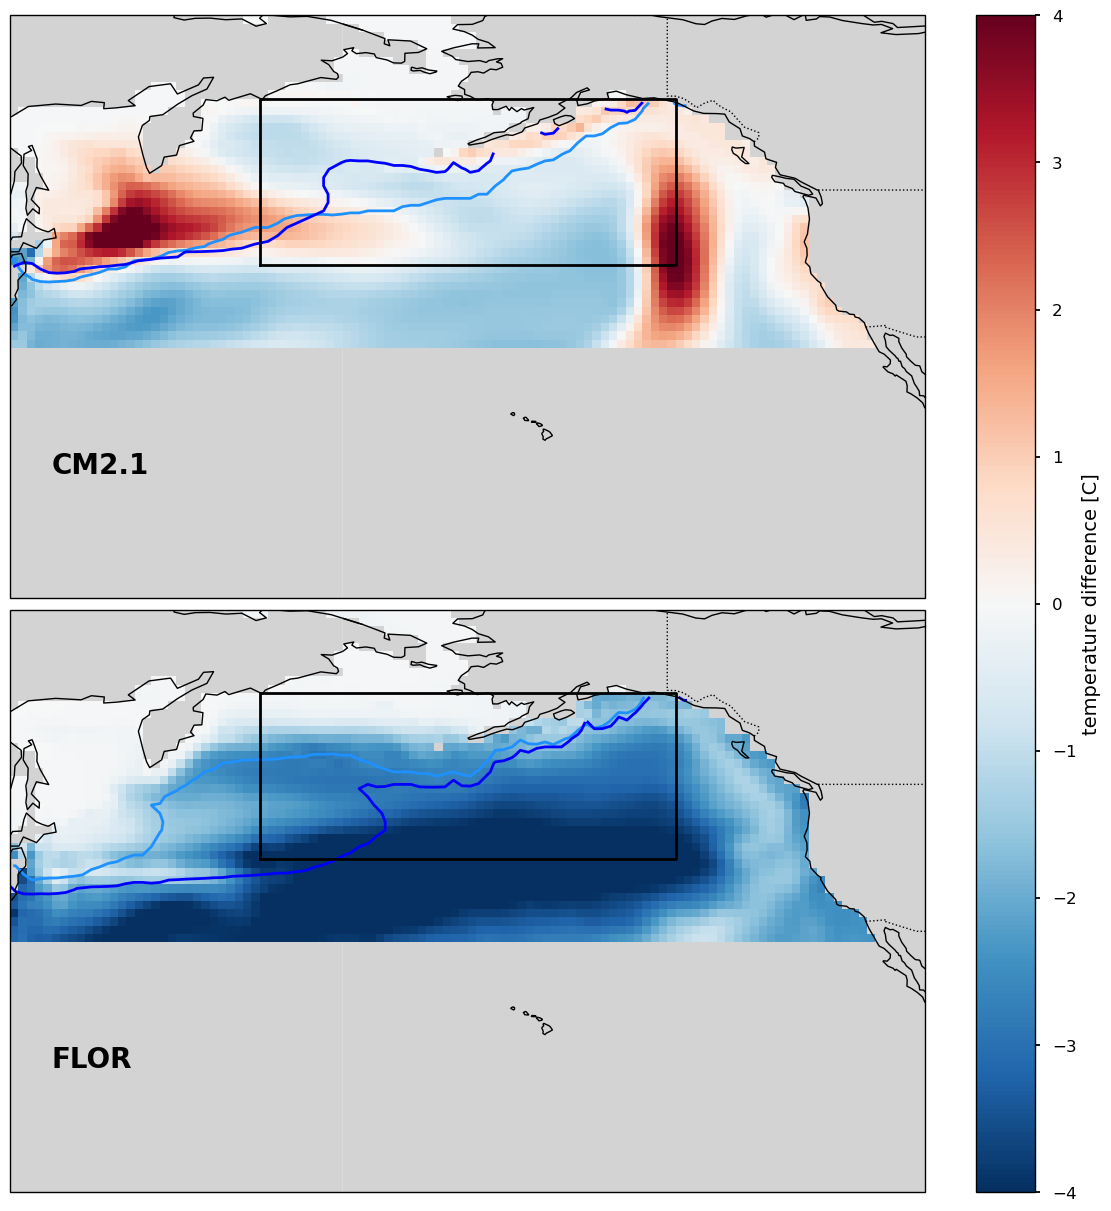

In [78]:
# import ice

fig, ax = plt.subplots(2,1,subplot_kw={'projection': ccrs.PlateCarree(central_longitude=-180)}, figsize=(12, 12))
p = plot_map(ax[0],CM21_diff.temp,modelname='CM2.1', lat1=40, lat2=60, lon1=-190, lon2=-140, vmin=-4, vmax=4)  # First map
plot_map(ax[1],FLOR_diff.temp,modelname='FLOR', lat1=40, lat2=60, lon1=-190, lon2=-140, vmin=-4, vmax=4)  # Second map

CM21_m6_ice_months = xr.open_dataarray('./processed_data/count_ice_months_MI_CM2.1p1_CTL1860_m6pctSolar.nc')
FLOR_m6_ice_months = xr.open_dataarray('./processed_data/count_ice_months_MI_FLOR_m6p0sol_CTL1860.nc')

plot_contours_icemonth_years(CM21_m6_ice_months, ax[0], color='dodgerblue',
                                       firstyear=0, lastyear=10)
plot_contours_icemonth_years(CM21_m6_ice_months, ax[0], color='b',
                                       firstyear=40, lastyear=50)
plot_contours_icemonth_years(FLOR_m6_ice_months, ax[1], color='dodgerblue',
                                       firstyear=0, lastyear=10)
plot_contours_icemonth_years(FLOR_m6_ice_months, ax[1], color='b',
                                       firstyear=40, lastyear=50)

fig.colorbar(p, ax=ax, label='temperature difference [C]')

# Plot T, S profiles in the box over time

In [7]:
def get_box_weighted_mean(da, lat1=40, lat2=60, lon1=-190, lon2=-140):
    # Subset the box
    da_box = da.sel(xt_ocean=slice(lon1, lon2),
                    yt_ocean=slice(lat1, lat2))
    
    # Get latitude weights (cosine of latitude in radians)
    lat_rad = np.deg2rad(da_box['yt_ocean'])
    weights = np.cos(lat_rad)
    
    # Ensure weights broadcast correctly
    weights, _ = xr.broadcast(weights, da_box)
    
    # Perform weighted mean
    #da_weighted_mean = (da_box * weights).sum(dim=('xt_ocean', 'yt_ocean')) / weights.sum(dim=('xt_ocean', 'yt_ocean'))
    da_weighted_mean = da_box.mean(('xt_ocean','yt_ocean'))
    
    return da_weighted_mean

In [8]:
# north Pacific (box)
CM21_ds_m6_NP = get_box_weighted_mean(CM21_ds_m6)
FLOR_ds_m6_NP = get_box_weighted_mean(FLOR_ds_m6)
CM21_ds_CTRL_NP = get_box_weighted_mean(CM21_ds_CTRL)
FLOR_ds_CTRL_NP = get_box_weighted_mean(FLOR_ds_CTRL)

In [9]:
# western boundary current region
CM21_ds_m6_WBC = get_box_weighted_mean(CM21_ds_m6, lat1=25, lat2=45, lon1=-220, lon2=-190)
FLOR_ds_m6_WBC = get_box_weighted_mean(FLOR_ds_m6, lat1=25, lat2=45, lon1=-220, lon2=-190)
CM21_ds_CTRL_WBC = get_box_weighted_mean(CM21_ds_CTRL, lat1=25, lat2=45, lon1=-220, lon2=-190)
FLOR_ds_CTRL_WBC = get_box_weighted_mean(FLOR_ds_CTRL, lat1=25, lat2=45, lon1=-220, lon2=-190)

In [10]:
# function for plotting profiles
import xarray as xr
import matplotlib.pyplot as plt

def plot_clim(ds_flor, ds_cm21, xlim1=None, xlim2=None, xlim3=None, suptitle=''):
    """
    Plot seasonal temperature, salinity, and density profiles for two models (FLOR and CM2.1).

    Parameters:
        ds_flor (xr.Dataset): Dataset for the FLOR model.
        ds_cm21 (xr.Dataset): Dataset for the CM2.1 model.
        xlim1 (tuple): x-axis limits for temperature plot.
        xlim2 (tuple): x-axis limits for salinity plot.
        xlim3 (tuple): x-axis limits for density plot.
        suptitle (str): Optional super title for the figure.
    """
    # Define seasonal groups
    seasons = {
        'JFM': [1, 2, 3],
        'AMJ': [4, 5, 6],
        'JAS': [7, 8, 9],
        'OND': [10, 11, 12]
    }

    # Define colors
    colors = {
        'JFM': 'blue',
        'AMJ': 'green',
        'JAS': 'orange',
        'OND': 'red'
    }

    # Set up figure and axes (2 rows x 3 columns)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True, sharex='col')

    model_names = ['FLOR', 'CM2.1']
    datasets = [ds_flor, ds_cm21]

    for row, (model_name, ds) in enumerate(zip(model_names, datasets)):
        # Sort by depth if needed
        ds = ds.sortby('st_ocean')

        # Temperature plot (column 0)
        for season, months in seasons.items():
            temp_mean = ds.temp.sel(month=months).mean(dim='month')
            axes[row, 0].plot(temp_mean, ds.st_ocean, label=season, color=colors[season])

        axes[row, 0].set_ylim(200, 0)
        
        if xlim1 is not None:
            axes[row, 0].set_xlim(xlim1)
        axes[row, 0].set_xlabel('Temperature (°C)')
        if row == 0:
            axes[row, 0].set_title('Temperature Profiles')
        axes[row, 0].set_ylabel('Depth (m)')
        axes[row, 0].legend()
        axes[row, 0].text(0.05, 0.95, model_name, transform=axes[row, 0].transAxes,
                         fontsize=12, fontweight='bold', va='top')

        # Salinity plot (column 1)
        for season, months in seasons.items():
            salt_mean = ds.salt.sel(month=months).mean(dim='month')
            axes[row, 1].plot(salt_mean, ds.st_ocean, label=season, color=colors[season])

        if xlim2 is not None:
            axes[row, 1].set_xlim(xlim2)
        axes[row, 1].set_xlabel('Salinity (psu)')
        if row == 0:
            axes[row, 1].set_title('Salinity Profiles')
        axes[row, 1].legend()

        # Density plot (column 2, from data)
        for season, months in seasons.items():
            rho_mean = ds.pot_rho_0.sel(month=months).mean(dim='month')
            axes[row, 2].plot(rho_mean, ds.st_ocean, label=season, color=colors[season])

        if xlim3 is not None:
            axes[row, 2].set_xlim(xlim3)
        axes[row, 2].set_xlabel('Density (kg/m³)')
        if row == 0:
            axes[row, 2].set_title('Density Profiles')
        axes[row, 2].legend()

    if suptitle:
        fig.suptitle(suptitle, fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()


In [11]:
# Control
CM21_ds_CTRL_NP_clim = CM21_ds_CTRL_NP.isel(time=slice(0,12*50)).groupby('time.month').mean('time')
FLOR_ds_CTRL_NP_clim = FLOR_ds_CTRL_NP.isel(time=slice(0,12*50)).groupby('time.month').mean('time')

# climatology for first 10 years
CM21_ds_m6_NP_clim_0_10 = CM21_ds_m6_NP.isel(time=slice(0,12*10)).groupby('time.month').mean('time')
FLOR_ds_m6_NP_clim_0_10 = FLOR_ds_m6_NP.isel(time=slice(0,12*10)).groupby('time.month').mean('time')

# climatology for years 20-30
CM21_ds_m6_NP_clim_20_30 = CM21_ds_m6_NP.isel(time=slice(12*20, 12*30)).groupby('time.month').mean('time')
FLOR_ds_m6_NP_clim_20_30 = FLOR_ds_m6_NP.isel(time=slice(12*20, 12*30)).groupby('time.month').mean('time')

# climatology for years 40-50
CM21_ds_m6_NP_clim_40_50 = CM21_ds_m6_NP.isel(time=slice(12*40, 12*50)).groupby('time.month').mean('time')
FLOR_ds_m6_NP_clim_40_50 = FLOR_ds_m6_NP.isel(time=slice(12*40, 12*50)).groupby('time.month').mean('time')

# climatology for years 90-100
CM21_ds_m6_NP_clim_90_100 = CM21_ds_m6_NP.isel(time=slice(12*90, 12*100)).groupby('time.month').mean('time')
FLOR_ds_m6_NP_clim_90_100 = FLOR_ds_m6_NP.isel(time=slice(12*90, 12*100)).groupby('time.month').mean('time')


In [33]:
import xarray as xr
import matplotlib.pyplot as plt

def plot_jfm_all_profiles(ds_dict_flor, ds_dict_cm21, suptitle='', ylim=None):
    
    # Plot JFM profiles (actual values) for temperature, salinity, and density 
    # for four time periods and two models (FLOR and CM2.1).
    
    # Inputs:
    # ds_dict_flor (dict): Dictionary of FLOR datasets, keys are period labels.
    # ds_dict_cm21 (dict): Dictionary of CM2.1 datasets, keys are period labels.
    # suptitle (str): Optional title for the full figure.

    variables = {
        'temp': {'label': 'Temperature', 'units': '[°C]', 'xlim': (-2, 6)},
        'salt': {'label': 'Salinity', 'units': '[psu]', 'xlim': (32.5, 35.5)},
        'pot_rho_0': {'label': 'Potential Density', 'units': '[kg/m³]', 'xlim': (1026, 1028)}
    }

    fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharey=True, sharex='col')
    model_names = ['FLOR', 'CM2.1']
    datasets = [ds_dict_flor, ds_dict_cm21]
    colors = ['grey', '#a6cee3', '#1f78b4', '#08519c', '#08306b']  # light to dark blue
    periods = list(ds_dict_flor.keys())  # assume same keys for both models

    for row, (model_name, ds_dict) in enumerate(zip(model_names, datasets)):
        for col, (var, meta) in enumerate(variables.items()):
            ax = axes[row, col]
            for i, period in enumerate(periods):
                ds = ds_dict[period].sortby('st_ocean')
                profile = ds[var].sel(month=[1, 2, 3]).mean(dim='month')
                ax.plot(profile, ds.st_ocean, label=period, color=colors[i])
            ax.grid(linestyle='--')
            ax.set_ylim(ylim)
            ax.set_xlim(meta['xlim'])
            if row == 1:
                ax.set_xlabel(meta['units'])
            if row == 0:
                ax.set_title(meta['label'])
            if col == 2:
                ax.legend(loc='best')
            ax.text(0.02, 0.95, model_name, transform=ax.transAxes, 
                    fontsize=12, fontweight='bold', va='top')

    if suptitle:
        fig.suptitle(suptitle, fontsize=16)
    fig.supylabel('Depth [m]')
    #plt.tight_layout()
    #plt.subplots_adjust(top=0.9)
    #plt.show()


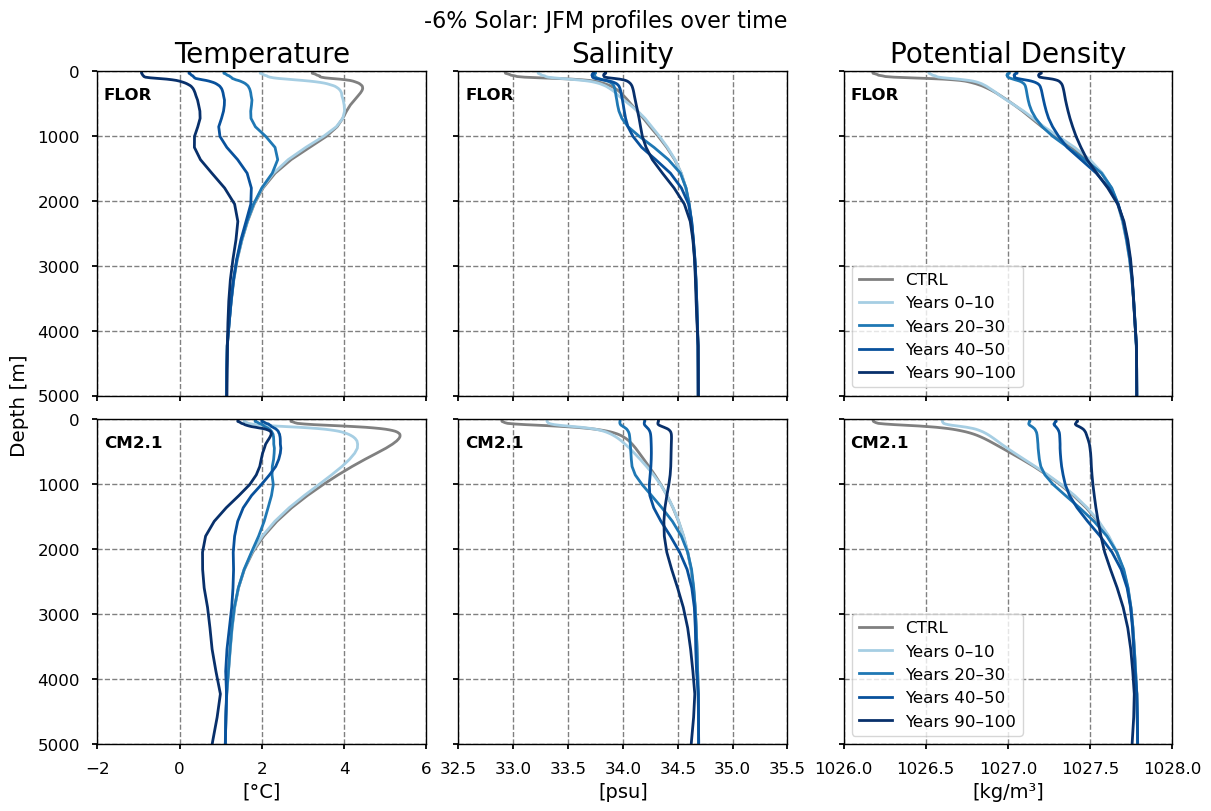

In [35]:
flor_dict = {
    'CTRL': FLOR_ds_CTRL_NP_clim,
    'Years 0–10': FLOR_ds_m6_NP_clim_0_10,
    'Years 20–30': FLOR_ds_m6_NP_clim_20_30,
    'Years 40–50': FLOR_ds_m6_NP_clim_40_50,
    'Years 90–100': FLOR_ds_m6_NP_clim_90_100,
}

cm21_dict = {
    'CTRL': CM21_ds_CTRL_NP_clim,
    'Years 0–10': CM21_ds_m6_NP_clim_0_10,
    'Years 20–30': CM21_ds_m6_NP_clim_20_30,
    'Years 40–50': CM21_ds_m6_NP_clim_40_50,
    'Years 90–100': CM21_ds_m6_NP_clim_90_100,
}

plot_jfm_all_profiles(flor_dict, cm21_dict, suptitle='-6% Solar: JFM profiles over time', ylim=(5000, 0))
plt.savefig('FigureS8.pdf', dpi=300)